# Toffoli Gate (CCX) Universal Reversible Computing
**Notebook:** Verification of the 3-qubit Toffoli gate and its use in reversible arithmetic

## Overview

The **Toffoli gate** (also called CCX or CCNOT) is a 3-qubit gate:
- 2 **control** qubits and 1 **target** qubit
- Flips the target if and only if **both** controls are $|1\rangle$

$$\text{Toffoli}|c_1, c_2, t\rangle = |c_1, c_2, t \oplus (c_1 \cdot c_2)\rangle$$

### Why it matters
- **Universal for reversible classical computing** â€” any classical logic circuit can be
  built from Toffoli gates (AND, NOT, fanout)
- **Universal for quantum computing** combined with Hadamard
- Used in quantum arithmetic (adders, multipliers) and error correction

### Truth table
| $c_1$ | $c_2$ | $t_{in}$ | $t_{out}$ |
|-------|-------|----------|-----------|
| 0 | 0 | 0 | 0 |
| 0 | 0 | 1 | 1 |
| 0 | 1 | 0 | 0 |
| 0 | 1 | 1 | 1 |
| 1 | 1 | 0 | **1** |
| 1 | 1 | 1 | **0** |

The gate is its own inverse: applying it twice returns to the original state.

### Reversibility and uncomputation
Quantum gates must be **reversible** (unitary). The Toffoli gate achieves classical AND
reversibly by keeping the inputs intact and writing the result to an ancilla qubit.
Uncomputation restores ancilla qubits to $|0\rangle$ after use.

## Testing CCNOT (Toffoli) gate using IBMQ

#### Load libraries

In [24]:
import os
from dotenv import load_dotenv
load_dotenv()

# pip install qiskit qiskit-aer qiskit-ibm-runtime
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from math import pi
from qiskit.visualization import plot_bloch_vector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import numpy as np


In [25]:
# --- IBM Quantum hardware setup ---
# Run once to save your credentials:
#   QiskitRuntimeService.save_account(channel='ibm_cloud', token='YOUR_TOKEN', overwrite=True)

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel='ibm_cloud', token=os.environ['IBM_QUANTUM_TOKEN'])

qiskit_runtime_service._discover_account:WARNING:2026-03-15 22:16:10,403: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-15 22:16:21,783: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


#### See which backends are available

In [26]:
# Choose backend (new API):
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# For local simulation:
backend = AerSimulator()

#### Create 3 Qbits and 3 classical measurement gates

In [27]:
qr=qk.QuantumRegister(3)
cr=qk.ClassicalRegister(3)
qc=qk.QuantumCircuit(qr,cr)

### Prepare the state of controlling Qbits
####  Let's choose Qbits 1 and 2 as controlling ones and Qbit 0 as the target one. Initially all Qbits are in |0> state


In [28]:
#qc.x(qr[2])
qc.x(qr[1])

#### Write the A and B gates which are the elements of the Toffoli gate


In [29]:
# A gate
qc.h(qr[0])
qc.cx(qr[2],qr[0])
qc.h(qr[0])

# B gate
qc.h(qr[0])
qc.tdg(qr[0])
qc.cx(qr[2],qr[0])
qc.t(qr[0])
qc.h(qr[0])

# A gate
qc.h(qr[0])
qc.cx(qr[1],qr[0])
qc.h(qr[0])

# B gate
qc.h(qr[0])
qc.tdg(qr[0])
qc.cx(qr[2],qr[0])
qc.t(qr[0])
qc.h(qr[0])

#### Create measurement gates in computational basis


In [30]:
measureZ=qk.QuantumCircuit(qr,cr)
measureZ.measure(qr,cr)

#### Create measurement gates in superposition basis


In [31]:
measureX=qk.QuantumCircuit(qr,cr)
measureX.h(qr)
measureX.measure(qr,cr)

#### Add measurement gates to the cirquit

In [32]:
#testZ=qc+measureZ
#testX=qc+measureX
testZ = qc.compose(measureZ)
testX = qc.compose(measureX)


In [33]:
#### See the structure of this circuit :

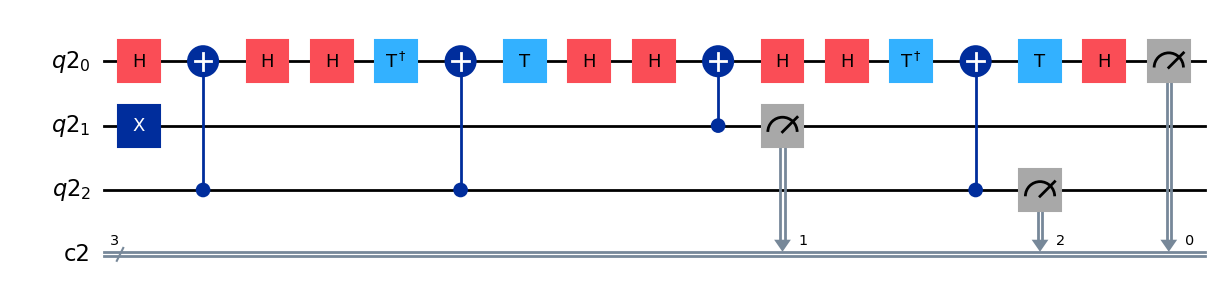

In [34]:
testZ.draw(output='mpl')

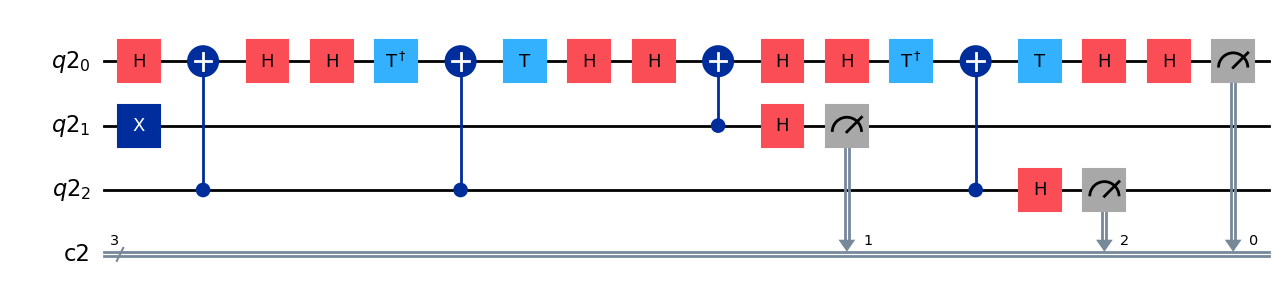

In [35]:
testX.draw(output='mpl')

### Run the algorithm

In [36]:
# Run on local AerSimulator (was: ibmq_qasm_simulator)
backend = AerSimulator()
result = backend.run(transpile([testZ, testX], backend), shots=1024).result()

c:\Users\mikes\Documents\QML\qiskit\.venv\Lib\site-packages\qiskit\result\result.py:372: UserWarning: Result object contained multiple results matching name "circuit-56", only first match will be returned. Use an integer index to retrieve results for all entries.
  warnings.warn(


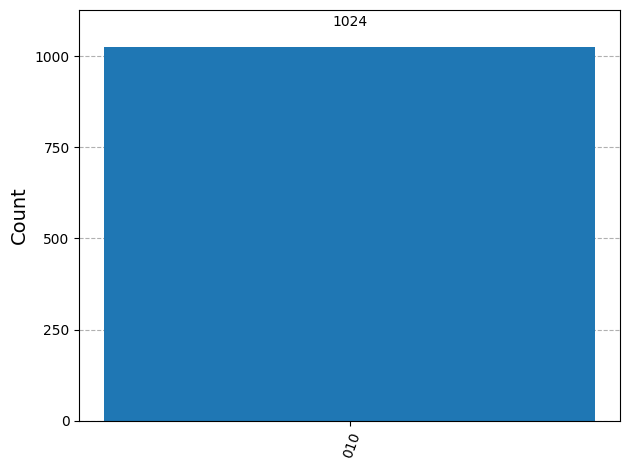

In [37]:
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ)) 


#### As the initial state is 010 it should not change by CCNOT. 
####    As we see real experiment gives this result with probability 0.854

### Let's try another input state, e.g. 011

In [38]:
qr=qk.QuantumRegister(3)
cr=qk.ClassicalRegister(3)
qc=qk.QuantumCircuit(qr,cr)

qc.x(qr[2])
qc.x(qr[1])

# A gate
qc.h(qr[0])
qc.cx(qr[2],qr[0])
qc.h(qr[0])

# B gate
qc.h(qr[0])
qc.tdg(qr[0])
qc.cx(qr[2],qr[0])
qc.t(qr[0])
qc.h(qr[0])

# A gate
qc.h(qr[0])
qc.cx(qr[1],qr[0])
qc.h(qr[0])

# B gate
qc.h(qr[0])
qc.tdg(qr[0])
qc.cx(qr[2],qr[0])
qc.t(qr[0])
qc.h(qr[0])

measureZ=qk.QuantumCircuit(qr,cr)
measureZ.measure(qr,cr)
testZ=qc.compose(measureZ)


#### Choose backend: Local qiskit simulator 

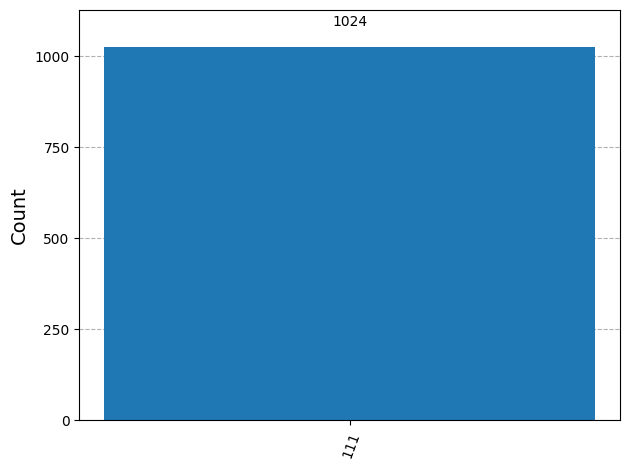

In [39]:
backend = AerSimulator()
result = backend.run(transpile([testZ], backend), shots=1024).result()
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ))

In [40]:
# Run on real IBM device (requires account setup):
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(testZ, backend_real)], shots=1024)
# result_counts = job.result()[0].data.c.get_counts()
# Using simulator as stand-in:
result_counts = result.get_counts(testZ)
print('(Using simulator results. Uncomment above for real hardware.)')

(Using simulator results. Uncomment above for real hardware.)


In [41]:
# Run on real IBM device (requires account setup)
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(testZ, backend_real)], shots=1024)
# result = job.result()

In [42]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from collections import Counter

service = QiskitRuntimeService(channel="ibm_cloud", token=os.environ["IBM_QUANTUM_TOKEN"])
backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
sampler = Sampler(backend_real)

job = sampler.run([transpile(testZ, backend_real)], shots=1024)

data = job.result()[0].data

# Get register names — works across qiskit-ibm-runtime versions
fields = list(vars(data).keys())
print("Registers:", fields)

# Combine per-shot bitstrings across all classical registers (correlated joint counts)
bitstring_lists = [getattr(data, f).get_bitstrings() for f in fields]
resultExp_counts = dict(Counter(" ".join(bits) for bits in zip(*bitstring_lists)))
print(resultExp_counts)


qiskit_runtime_service._discover_account:WARNING:2026-03-15 22:16:24,143: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-15 22:16:35,262: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-15 22:16:35,958: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-15 22:16:40,521: Using instance: open-instance, plan: open


Registers: ['c3']
{'111': 969, '110': 31, '011': 12, '010': 8, '101': 2, '100': 2}


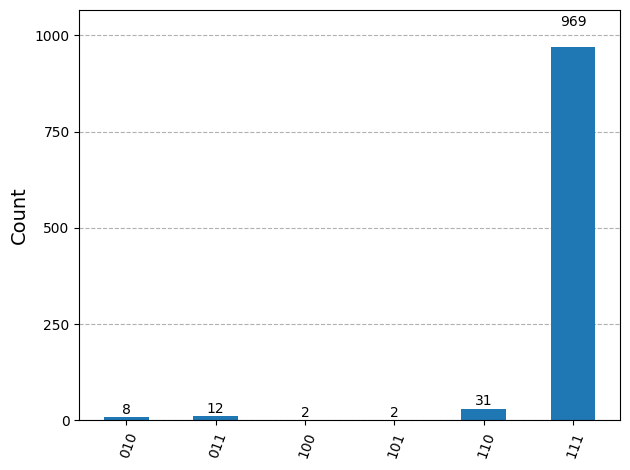

In [43]:
from qiskit.visualization import plot_histogram
plot_histogram(resultExp_counts) 